# Practical 7: Random Forests, OOB Error, Bagging and Feature Subsampling

## Titanic Survival Prediction

### Aim
Implement and analyse Random Forests using **training and validation data**, study **OOB error convergence**, compare `max_features`, demonstrate **manual bootstrap bagging**, calculate **permutation importance**, and compare a Random Forest with a single Decision Tree.

### Key points
- **Decision Tree:** one person makes the decision.
- **Bagging:** ask many trees, each trained on a different bootstrap sample.
- **Random Forest:** many trees + bootstrap samples + random feature selection.
- **OOB:** passengers left out of a tree's bootstrap sample can help evaluate that tree.
- **Permutation importance:** shuffle one feature and see how much model accuracy changes.

### CSV
Uses the Titanic dataset (`titanic.csv`, 891 passengers).

Columns used: `Pclass, Sex, Age, Fare` → `Survived`

Change `CSV_PATH` below if your filename is different.

> The dataset is large, so the OOB and validation curves are much more stable than they would be on a tiny teaching dataset.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

In [2]:
# ============================================================
# 2. LOAD CSV DATASET
# ============================================================

# Change this filename to your actual CSV filename.

CSV_PATH = r"C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\data\titanic.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

COLS = ['Pclass', 'Sex', 'Age', 'Fare', 'Survived']
YESNO_COLS = []

# Create a copy so that the original dataset remains unchanged.
data_model = df[COLS].copy()

# Convert text categories to numbers.
data_model["Sex"] = data_model["Sex"].astype(str).str.strip().str.lower().map({"female": 0, "male": 1})

# Check the result.
print("Preprocessed dataset:")
display(data_model.head())

print("\nMissing values:")
print(data_model.isna().sum())

print("\nData types:")
print(data_model.dtypes)

Preprocessed dataset:


,Pclass,Sex,Age,Fare,Survived
0,3,1,22.0,7.2500,0
1,1,0,38.0,71.2833,1
2,3,0,26.0,7.9250,1
3,1,0,35.0,53.1000,1
4,3,1,35.0,8.0500,0



Missing values:
Pclass        0
Sex           0
Age         177
Fare          0
Survived      0
dtype: int64

Data types:
Pclass        int64
Sex           int64
Age         float64
Fare        float64
Survived      int64
dtype: object


In [4]:
# ============================================================
# 4. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["Survived"])
y = data_model["Survived"]

print("Features:", X.columns.tolist())
print("Target: Survived")

Features: ['Pclass', 'Sex', 'Age', 'Fare']
Target: Survived


## Step 1 — Training Data and Validation/Test Data

Think of it simply:

- **Training data:** the rows the model learns from.
- **Validation/test data:** rows kept aside to check performance on unseen data.

We use the same split throughout this practical so the models are compared fairly.

In [5]:
# ============================================================
# 5. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Fill any missing values using the median learned from the training rows only.
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training samples: 623
Validation samples: 268

Training class distribution:
Survived
0    384
1    239
Name: count, dtype: int64

Validation class distribution:
Survived
0    165
1    103
Name: count, dtype: int64


# Part A — Single Decision Tree Baseline

First build one Decision Tree. This is our baseline.

Then we will build a Random Forest and ask:

**Does many trees work better than one tree?**

In [6]:
# ============================================================
# 6. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")

SINGLE DECISION TREE
Training Accuracy   : 0.9743
Validation Accuracy : 0.7836
Tree Depth          : 29
Number of Leaves    : 148


# Part B — Random Forest

A Random Forest creates many Decision Trees.

Important parameters:

- `n_estimators` → number of trees.
- `bootstrap=True` → each tree gets a bootstrap sample.
- `oob_score=True` → calculate Out-of-Bag accuracy.
- `max_features` → random feature subsampling at each split.

In [7]:
# ============================================================
# 7. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")

RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 0.9743
Validation Accuracy : 0.8097
OOB Accuracy        : 0.8170
OOB Error           : 0.1830


In [8]:
len(rf.estimators_)

100

In [9]:
print(rf.estimators_[0])

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


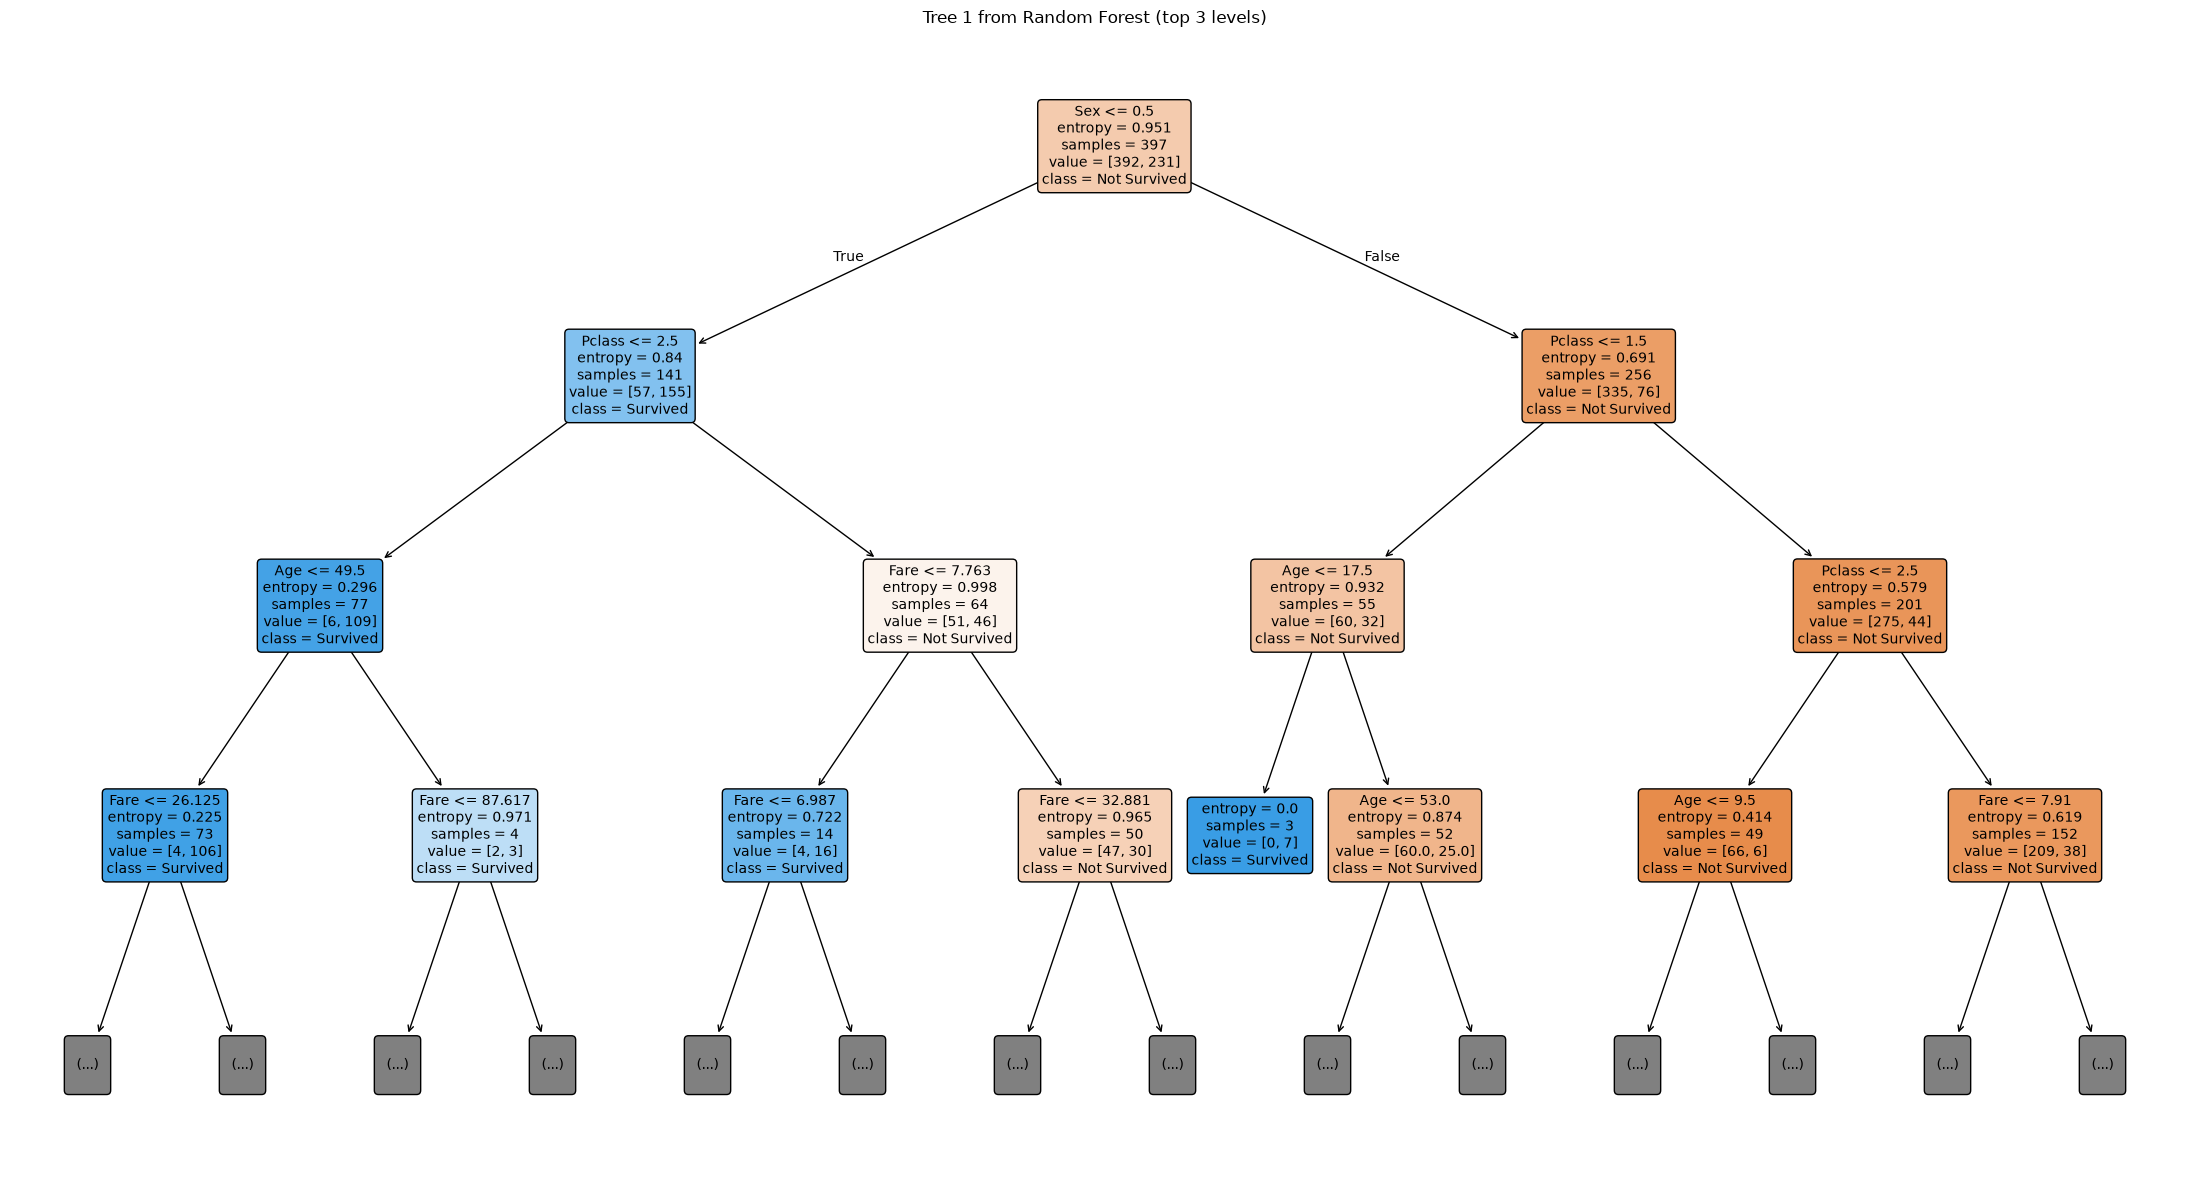

In [10]:
# ============================================================
# IMPORT plot_tree
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Fully grown trees are very large on this dataset, so only the top 3 levels are drawn.
plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    max_depth=3,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 1 from Random Forest (top 3 levels)")
plt.tight_layout()
plt.show()

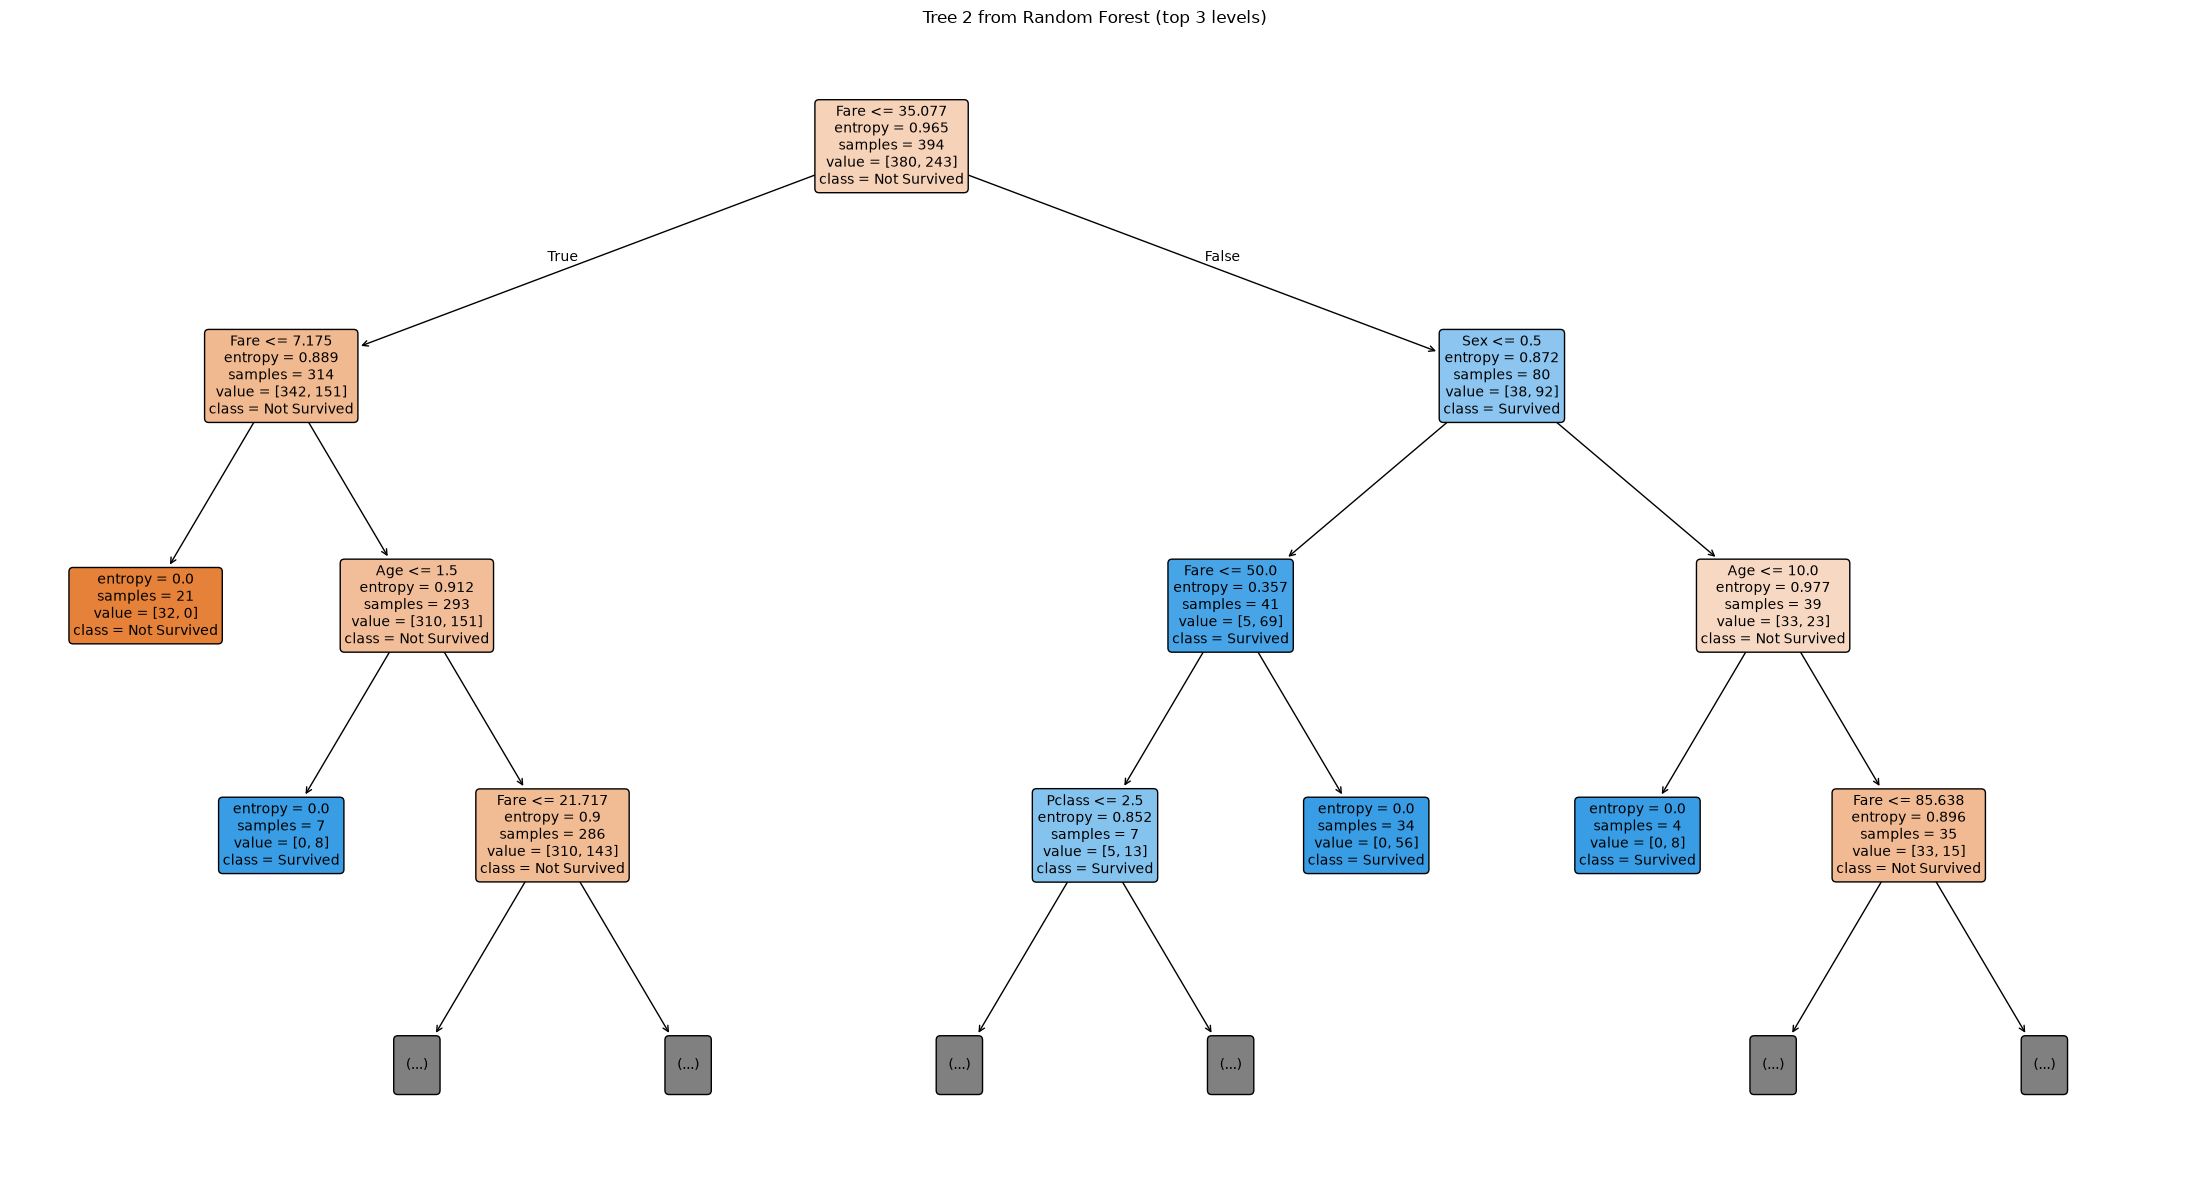

In [11]:
plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[1],
    max_depth=3,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 2 from Random Forest (top 3 levels)")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 8. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["Not Survived", "Survived"],
    zero_division=0
))

              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       165
    Survived       0.77      0.72      0.74       103

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268



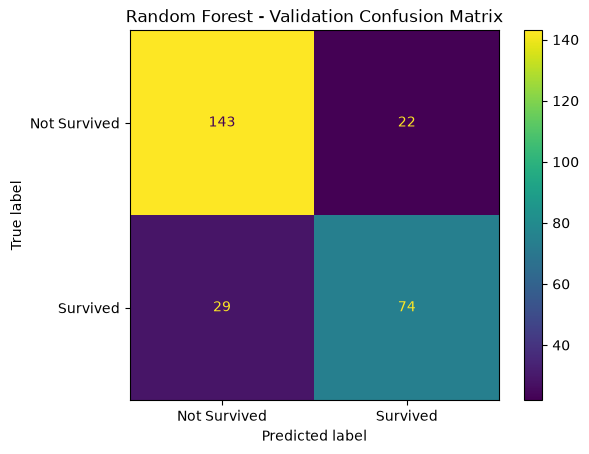

In [13]:
# ============================================================
# 9. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

# Part C — OOB Error Convergence

For each tree, some training observations are not selected in its bootstrap sample. These are **Out-of-Bag (OOB)** observations for that tree.

As more trees are added, the OOB estimate usually becomes more stable.

We record OOB accuracy and OOB error for different numbers of trees.

In [14]:
# ============================================================
# 10. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))

C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used 

,n_estimators,OOB_acc,OOB_error
0,1,0.6581,0.3419
1,5,0.7705,0.2295
2,10,0.8026,0.1974
3,20,0.8042,0.1958
4,30,0.8106,0.1894
5,50,0.8042,0.1958
6,75,0.8026,0.1974
7,100,0.8170,0.1830
8,150,0.8122,0.1878
9,200,0.8202,0.1798


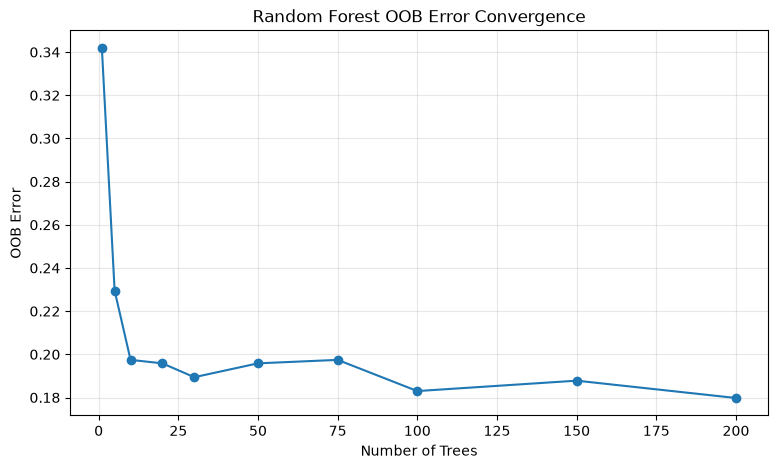

In [15]:
# ============================================================
# 11. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()

### Student observation
Look for the region where OOB error becomes relatively stable.

With very few trees some rows have no OOB prediction, so the first points can be unreliable; after a few dozen trees the curve flattens.

# Part D — `max_features` Comparison

`max_features` controls how many features are considered when a tree searches for a split.

We compare:

- `sqrt`
- `log2`
- `None` → all features

This demonstrates **feature subsampling**.

In [16]:
# ============================================================
# 12. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))

,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,0.9743,0.8097,0.8170,0.1830
1,log2,0.9743,0.8097,0.8170,0.1830
2,None,0.9743,0.7985,0.8186,0.1814


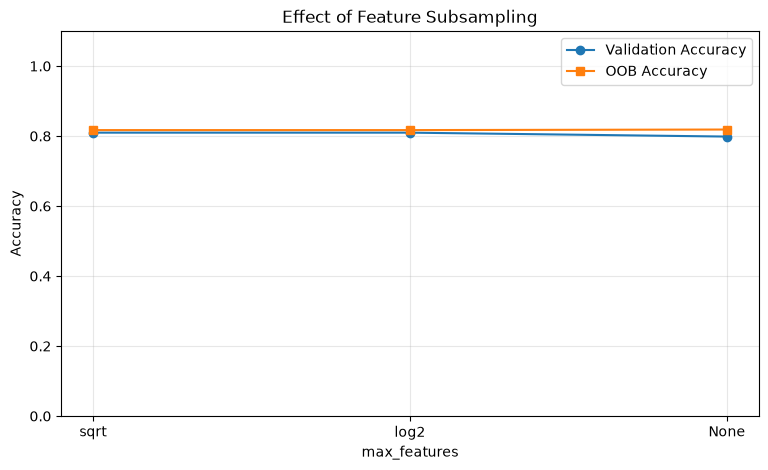

In [17]:
# ============================================================
# 13. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()

# Part E — Manual Bootstrap Bagging

### Layman idea

Suppose the training set has rows:

`R1, R2, R3, R4, ...`

For one tree we randomly select rows **with replacement**.

A bootstrap sample might look like:

`R1, R3, R3, R5, R7, R1, ...`

Another tree receives a different sample.

This section manually demonstrates the idea before using scikit-learn's BaggingClassifier.

In [18]:
# ============================================================
# 14. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices (first 20):")
print(indices[:20])

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))
print(f"OOB fraction: {len(oob_indices) / len(X_train):.3f}  (about 0.368 = 1/e for large samples)")

Bootstrap indices (first 20):
[ 55 482 407 273 269 534  53 434 125  58 327 607 458 474 446 489 319  79
 523 280]

Total bootstrap observations: 623
Unique observations: 406
OOB observations: 217
OOB fraction: 0.348  (about 0.368 = 1/e for large samples)


In [19]:
# ============================================================
# 15. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    # Draw a bootstrap sample from training rows.
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")

50 manually bagged trees trained.


In [20]:
# ============================================================
# 16. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation rows.
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Majority vote across all trees.
manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)

Manual Bootstrap Bagging Validation Accuracy: 0.8209


# Part F — scikit-learn BaggingClassifier

The previous cells showed the mechanism manually.

Now `BaggingClassifier` automates bootstrap sampling and combines the tree predictions.

**Bagging vs Random Forest:**
- Bagging mainly uses bootstrap samples.
- Random Forest additionally introduces random feature selection at splits.

In [21]:
# ============================================================
# 17. BAGGING CLASSIFIER
# ============================================================

# Compatible with newer scikit-learn versions.
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")

BAGGING PERFORMANCE
Training Accuracy   : 0.9743
Validation Accuracy : 0.7985


# Part G — Permutation Importance

### Layman idea

1. Measure normal validation accuracy.
2. Shuffle one feature.
3. Predict again.
4. If accuracy drops a lot, that feature was important.
5. If accuracy changes little, that feature contributed less.

We calculate it on the validation set.

In [22]:
# ============================================================
# 18. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))

,Feature,Mean_Importance,Std_Importance
0,Sex,0.2015,0.0206
1,Pclass,0.1055,0.0150
2,Age,0.0585,0.0177
3,Fare,0.0442,0.0156


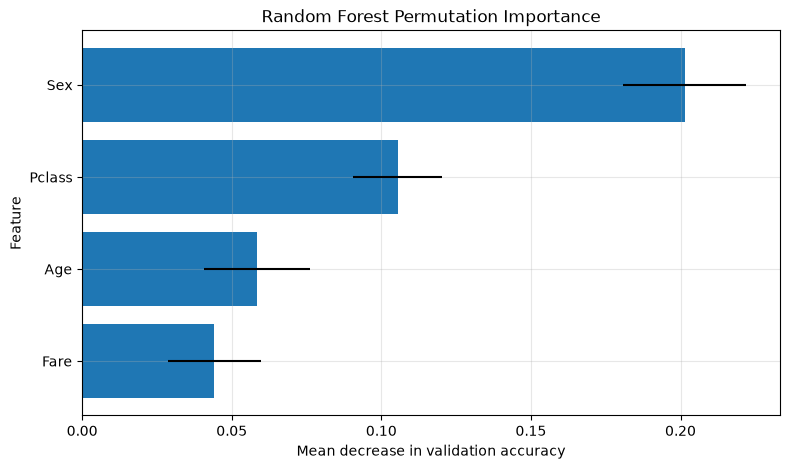

In [23]:
# ============================================================
# 19. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

# Part H — `rf_vs_single_tree()` Function

This is the main reusable experiment.

The function receives:

`X_train, y_train, X_val, y_val, n_estimators_list`

and returns:

`[n_estimators, RF_val_acc, DT_val_acc, OOB_acc]`

It also plots the requested **three lines**.

In [24]:
# ============================================================
# 20. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    """Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame with columns:
        n_estimators, RF_val_acc, DT_val_acc, OOB_acc

    Also plots three lines:
        1. Random Forest validation accuracy
        2. Single Decision Tree validation accuracy
        3. Random Forest OOB accuracy
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------
    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used 

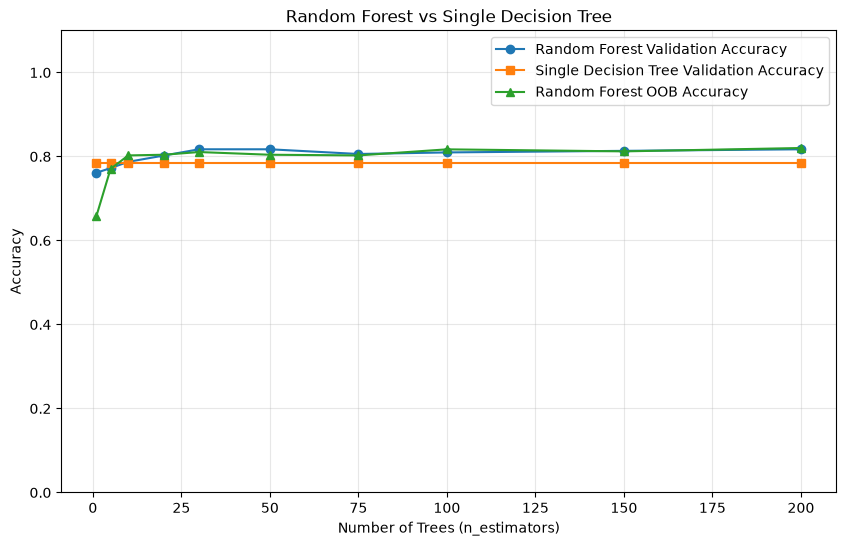

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.7612,0.7836,0.6581
1,5,0.7724,0.7836,0.7705
2,10,0.7873,0.7836,0.8026
3,20,0.8022,0.7836,0.8042
4,30,0.8172,0.7836,0.8106
5,50,0.8172,0.7836,0.8042
6,75,0.8060,0.7836,0.8026
7,100,0.8097,0.7836,0.8170
8,150,0.8134,0.7836,0.8122
9,200,0.8172,0.7836,0.8202


In [25]:
# ============================================================
# 21. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))

In [26]:
# ============================================================
# 22. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())

Best Random Forest result based on validation accuracy:
n_estimators    30.000000
RF_val_acc       0.817164
DT_val_acc       0.783582
OOB_acc          0.810594


# Part I — Overall Model Comparison

In [27]:
# ============================================================
# 23. OVERALL COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Random Forest",
        "Manual Bootstrap Bagging",
        "BaggingClassifier"
    ],
    "Training Accuracy": [
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        np.nan,
        accuracy_score(y_train, bagging_train_pred)
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, dt_val_pred),
        accuracy_score(y_val, rf_val_pred),
        manual_bagging_acc,
        accuracy_score(y_val, bagging_val_pred)
    ],
    "OOB Accuracy": [
        np.nan,
        rf.oob_score_,
        np.nan,
        np.nan
    ]
})

display(overall_comparison.round(4))

,Model,Training Accuracy,Validation Accuracy,OOB Accuracy
0,Single Decision Tree,0.9743,0.7836,NaN
1,Random Forest,0.9743,0.8097,0.817
2,Manual Bootstrap Bagging,NaN,0.8209,NaN
3,BaggingClassifier,0.9743,0.7985,NaN


# Final Learning Summary

Students should be able to explain:

1. How Random Forest combines many Decision Trees.
2. How bootstrap sampling creates different training sets.
3. What OOB observations are.
4. How OOB error changes as the number of trees increases.
5. What `max_features` means.
6. Why feature subsampling makes trees different.
7. How manual bagging works.
8. How permutation importance identifies influential features.
9. Whether Random Forest improves over a single Decision Tree on the validation data.
10. Why a single train/validation split gives only one estimate of performance, and how OOB accuracy offers a second, independent estimate.